# WSD, WSD-Beta, and Cosine Comparison

This notebook compares the three 10k-step schedule runs kept for the report.


In [16]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

## Load Runs

The selected logs are the 10k FineWeb runs used in the final comparison.


In [17]:
def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f if line.strip())

ROOT = Path("..")

wsd_raw      = read_jsonl(ROOT / "logs/wsd_intermediate_10k_20260606-071741/metrics.jsonl")
wsd_beta_raw = read_jsonl(ROOT / "logs/wsd_beta_intermediate_10k_20260606-082147/metrics.jsonl")
cosine_raw   = read_jsonl(ROOT / "logs/cosine_intermediate_10k_20260606-162651/metrics.jsonl")

MAX_STEPS = 10000
WSD_DECAY_START = 9000
FINAL_LR_RATIO = 0.01

def split(raw):
    train = raw[raw["train_loss"].notna()].reset_index(drop=True)
    val   = raw[raw["validation_loss"].notna()].reset_index(drop=True) if "validation_loss" in raw.columns else None
    return train, val

wsd_train,      wsd_val      = split(wsd_raw)
wsd_beta_train, wsd_beta_val = split(wsd_beta_raw)
cosine_train,   cosine_val   = split(cosine_raw)

for name, train_df, val_df in [
    ("WSD", wsd_train, wsd_val),
    ("WSD-beta", wsd_beta_train, wsd_beta_val),
    ("Cosine", cosine_train, cosine_val),
]:
    print(f"{name:8s} steps={int(train_df['step'].min())}-{int(train_df['step'].max())}  final_val={val_df['validation_loss'].iloc[-1]:.4f}")

WSD      steps=5-10000  final_val=3.4422
WSD-beta steps=5-10000  final_val=3.4874
Cosine   steps=5-10000  final_val=3.4770


## Training and Validation Loss

This overview checks whether the schedules differ in final validation loss and training dynamics.


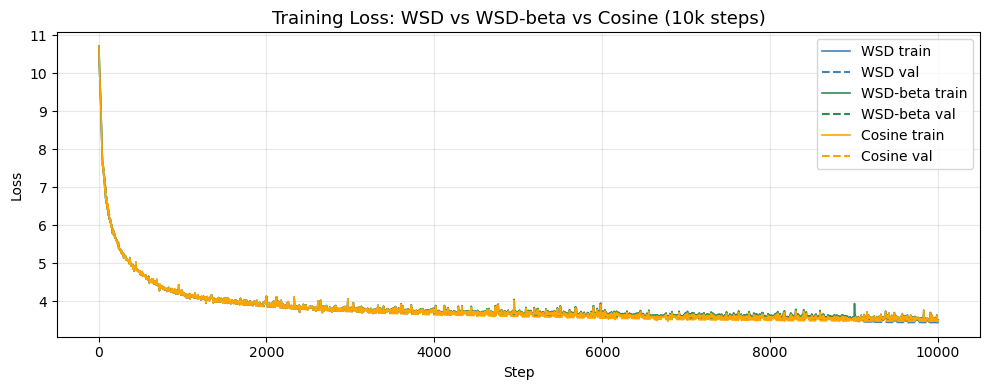

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))

runs = [
    (wsd_train,      wsd_val,      "steelblue", "WSD"),
    (wsd_beta_train, wsd_beta_val, "seagreen",  "WSD-beta"),
    (cosine_train,   cosine_val,   "orange",    "Cosine"),
]

for train_df, val_df, color, name in runs:
    ax.plot(train_df["step"], train_df["train_loss"], color=color, linewidth=1.2, label=f"{name} train")
    if val_df is not None and len(val_df) > 0:
        ax.plot(val_df["step"], val_df["validation_loss"], color=color, linewidth=1.5, linestyle="--", label=f"{name} val")

ax.set_title("Training Loss: WSD vs WSD-beta vs Cosine (10k steps)", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Validation Loss Near Decay

The zoom focuses on the region where WSD begins its final decay.


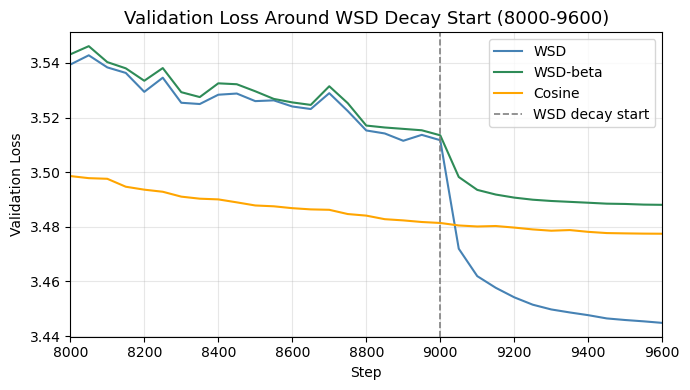

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))

runs = [
    (wsd_val,      "steelblue", "WSD"),
    (wsd_beta_val, "seagreen",  "WSD-beta"),
    (cosine_val,   "orange",    "Cosine"),
]

ZOOM_START, ZOOM_END = 8000, 9600

for val_df, color, name in runs:
    if val_df is not None and len(val_df) > 0:
        mask = val_df["step"].between(ZOOM_START, ZOOM_END)
        ax.plot(val_df.loc[mask, "step"], val_df.loc[mask, "validation_loss"],
                color=color, linewidth=1.5, label=name)

ax.axvline(WSD_DECAY_START, color="gray", linewidth=1.2, linestyle="--", label="WSD decay start")
ax.set_xlim(ZOOM_START, ZOOM_END)
ax.set_title(f"Validation Loss Around WSD Decay Start ({ZOOM_START}-{ZOOM_END})", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Learning Rate Schedules

WSD and WSD-beta share the same LR schedule; WSD-beta additionally decays Adam beta values.


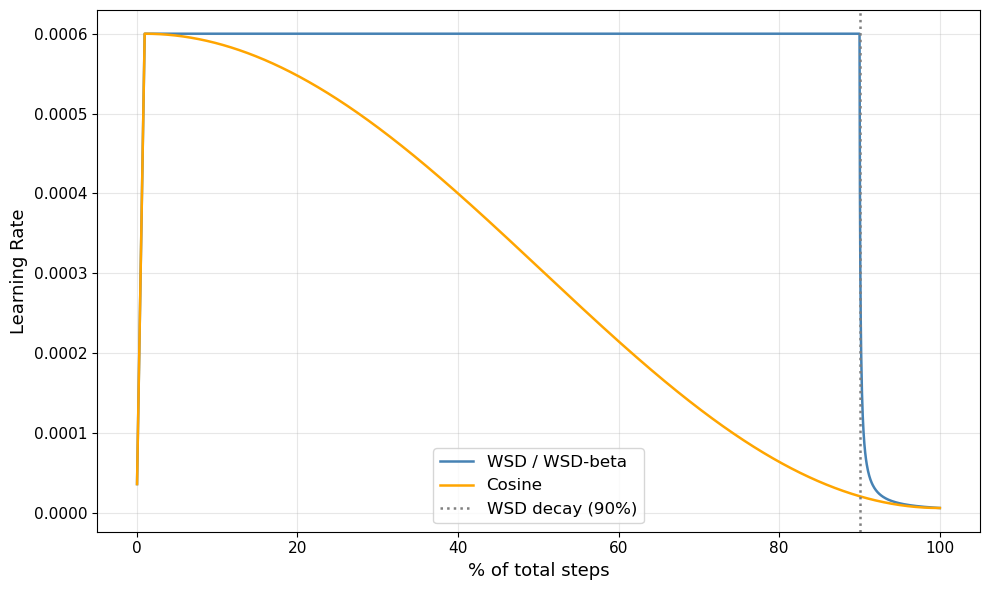

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(100 * wsd_train["step"] / MAX_STEPS,    wsd_train["learning_rate"],    color="steelblue", linewidth=1.8, label="WSD / WSD-beta")
ax.plot(100 * cosine_train["step"] / MAX_STEPS, cosine_train["learning_rate"], color="orange",    linewidth=1.8, label="Cosine")

ax.axvline(100 * WSD_DECAY_START / MAX_STEPS, color="gray", linewidth=1.8, linestyle=":",
           label=f"WSD decay ({100 * WSD_DECAY_START / MAX_STEPS:.0f}%)")

ax.set_xlabel("% of total steps", fontsize=13)
ax.set_ylabel("Learning Rate", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()